# Especialista *prestart* H60: resultado base y diagnóstico de volatilidad

Este cuaderno presenta el resultado del candidato final sobre el bloque fuera de muestra (6–10 jun 2026), distinguiendo **dos niveles de evidencia que no deben confundirse**:

1. el **resultado base** del especialista congelado, sin ningún filtro decidido sobre esos datos;
2. un **diagnóstico *post-hoc*** del régimen de volatilidad, que genera una hipótesis pero no es una segunda validación.

Se cargan los artefactos publicados: el resumen (`results/final_candidate_summary.csv`) y el ledger anonimizado de unidades de acción (`results/final_candidate_actions_anonymized.csv`).

In [1]:
import pandas as pd
s = pd.read_csv('../results/final_candidate_summary.csv')
piv = (s[s['metric'].str.startswith('mean_net_cost') | s['metric'].eq('n_actions')]
        .pivot_table(index='scope', columns='metric', values='value'))
piv = piv.reindex(['base_oos','low_vol_posthoc','high_vol_posthoc'])
piv[['n_actions','mean_net_cost_0p25','mean_net_cost_0p5','mean_net_cost_1p0']].round(3)

metric,n_actions,mean_net_cost_0p25,mean_net_cost_0p5,mean_net_cost_1p0
scope,,,,
base_oos,754.0,0.537,0.349,-0.026
low_vol_posthoc,318.0,1.258,1.069,0.691
high_vol_posthoc,435.0,0.004,-0.183,-0.558


## 1. Resultado base (sin filtro) — la validación limpia

El especialista congelado selecciona **754 unidades de acción** y obtiene **+0,349 ticks** al coste de referencia. El promedio es positivo en **tres de cinco días** y pasa a ser **ligeramente negativo ($-0{,}026$) bajo el coste de estrés**. Es una señal modesta donde los modelos anteriores fracasaban, no una rentabilidad demostrada.

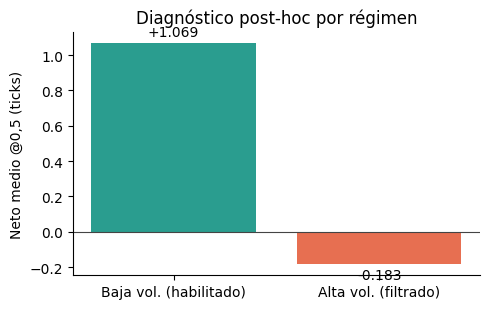

In [2]:
import matplotlib.pyplot as plt
led = pd.read_csv('../results/final_candidate_actions_anonymized.csv')
by_reg = led.groupby('volatility_regime')['net_cost_0p5'].mean().reindex(['low','high'])
fig, ax = plt.subplots(figsize=(5,3.2))
ax.bar(['Baja vol. (habilitado)','Alta vol. (filtrado)'], by_reg.values,
       color=['#2a9d8f','#e76f51'])
ax.axhline(0,color='#444',lw=0.8); ax.spines[['top','right']].set_visible(False)
ax.set_ylabel('Neto medio @0,5 (ticks)'); ax.set_title('Diagnóstico post-hoc por régimen')
for i,v in enumerate(by_reg.values): ax.annotate(f'{v:+.3f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',xytext=(0,3 if v>=0 else -3),textcoords='offset points')
plt.tight_layout(); plt.show()

## 2. Diagnóstico *post-hoc* del filtro de volatilidad

Al inspeccionar el bloque se observó un cambio de régimen (más sesiones de alta volatilidad). Si se separan las acciones por el umbral de volatilidad de entrenamiento, el subconjunto de baja volatilidad (318 acciones) es claramente positivo y el de alta volatilidad, negativo.

Ese subconjunto alcanza **+1,069 ticks** al coste de referencia, pero **la decisión de aplicar el filtro se tomó tras ver el bloque**, así que es un diagnóstico exploratorio, no confirmatorio. Con un *bootstrap* agrupado por mercado (el honesto, porque hay hasta 8 acciones por mercado) el intervalo de confianza al 90 % es **[+0,193, +2,004]** y la probabilidad de neto positivo, **97,6 %**. Queda **pendiente de validación prospectiva**.

Coherente con la memoria (Cap. 4): el resultado defendible es el base (+0,349); el filtro es una hipótesis congelada para validar con datos futuros.